In [12]:
import pandas as pd
import numpy as np

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt
import seaborn as sns

# import warnings
# warnings.filterwarnings('ignore')

In [3]:
# 데이터 로드
df_growth = pd.read_csv('../data/df_growth_year.csv')
df_merge = pd.read_csv('../data/df_merge_ver.csv')

In [4]:
# 필요한 컬럼만 추출 후 조인
df_growth = df_growth[['자치구명', '기준연도', 'sh_closure_growth_ratio']]
df_merge = df_merge.rename(columns={'기준년도': '기준연도'})
df = df_merge.merge(df_growth, on=['자치구명', '기준연도'], how='inner')

In [5]:
print(f"병합 결과: {df.shape[0]}행, {df.shape[1]}열")

병합 결과: 100행, 22열


## [1] 데이터 탐색

In [6]:
df.head(5)

,기준연도,자치구명,총_유동인구_수,연령대_10_유동인구_수,연령대_20_유동인구_수,연령대_30_유동인구_수,연령대_40_유동인구_수,연령대_50_유동인구_수,연령대_60_이상_유동인구_수,총_직장_인구_수,...,연령대_30_직장_인구_수,연령대_40_직장_인구_수,연령대_50_직장_인구_수,연령대_60_이상_직장_인구_수,1층 임대료,1층외 임대료,전체 임대료,전체점포수,프랜차이즈비율(%),sh_closure_growth_ratio
0,2020,종로구,269448773,27795541,47778447,43352079,45191946,43972157,61358604,230875,...,67823,64783,40269,14680,206900,138208,172554,27855.0,15.29,-1.560296
1,2020,중구,237541555,18094522,38562734,47087623,43270859,39198095,51327720,415266,...,131210,103097,66102,22496,250304,238701,244502,26090.0,19.66,-7.990367
2,2020,용산구,270388358,32635562,43235424,53080308,46913789,37655020,56868255,146887,...,44607,37531,24514,7812,136757,95126,115942,20680.0,14.33,3.228649
3,2020,성동구,312557080,44252802,51276012,55616126,49779633,45246523,66385982,60218,...,14550,14478,12931,8189,121642,83610,102626,17944.0,19.90,-0.555175
4,2020,광진구,388269890,57166834,72263563,64778173,58802233,56157993,79101093,48840,...,10064,12026,12941,6334,119052,73968,96510,21362.0,20.52,-1.336584


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   기준연도                     100 non-null    int64  
 1   자치구명                     100 non-null    object 
 2   총_유동인구_수                 100 non-null    int64  
 3   연령대_10_유동인구_수            100 non-null    int64  
 4   연령대_20_유동인구_수            100 non-null    int64  
 5   연령대_30_유동인구_수            100 non-null    int64  
 6   연령대_40_유동인구_수            100 non-null    int64  
 7   연령대_50_유동인구_수            100 non-null    int64  
 8   연령대_60_이상_유동인구_수         100 non-null    int64  
 9   총_직장_인구_수                100 non-null    int64  
 10  연령대_10_직장_인구_수           100 non-null    int64  
 11  연령대_20_직장_인구_수           100 non-null    int64  
 12  연령대_30_직장_인구_수           100 non-null    int64  
 13  연령대_40_직장_인구_수           100 non-null    int64  
 14  연령대_50_직장_인구_수           10

In [9]:
df = df.astype({col: 'int64' for col in df.select_dtypes(include=['bool']).columns})

<Axes: >

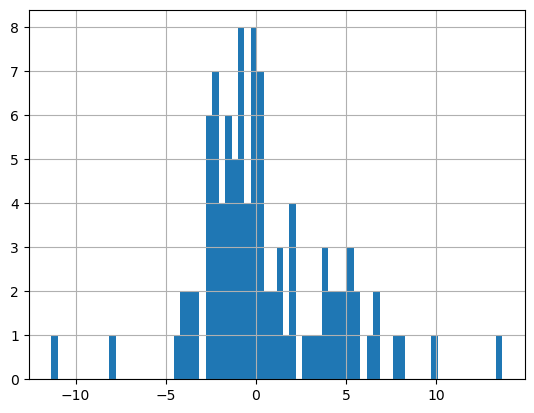

In [10]:
# 종속변수 탐색하기
df['sh_closure_growth_ratio'].hist(bins=70)

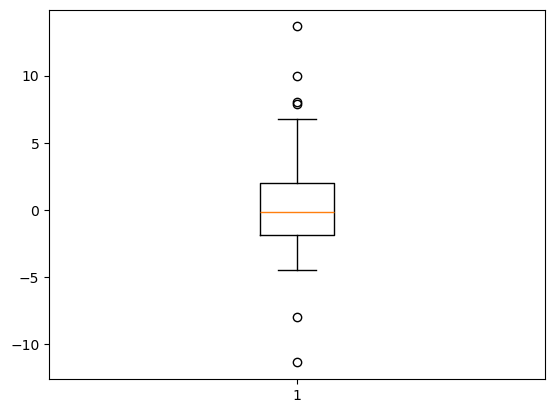

In [13]:
### 박스 플롯(boxplot)을 통해 아웃라이어 확인

plt.boxplot(df['sh_closure_growth_ratio'])
plt.show()

In [14]:
df.columns

Index(['기준연도', '자치구명', '총_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '총_직장_인구_수', '연령대_10_직장_인구_수', '연령대_20_직장_인구_수', '연령대_30_직장_인구_수',
       '연령대_40_직장_인구_수', '연령대_50_직장_인구_수', '연령대_60_이상_직장_인구_수', '1층 임대료',
       '1층외 임대료', '전체 임대료', '전체점포수', '프랜차이즈비율(%)', 'sh_closure_growth_ratio'],
      dtype='object')

In [15]:
## 변수 간 상관관계 탐색
cols = ['기준연도', '총_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '총_직장_인구_수', '연령대_10_직장_인구_수', '연령대_20_직장_인구_수', '연령대_30_직장_인구_수',
       '연령대_40_직장_인구_수', '연령대_50_직장_인구_수', '연령대_60_이상_직장_인구_수', '1층 임대료',
       '1층외 임대료', '전체 임대료', '전체점포수', '프랜차이즈비율(%)', 'sh_closure_growth_ratio']

corr = df[cols].corr(method = 'pearson')
corr

,기준연도,총_유동인구_수,연령대_10_유동인구_수,연령대_20_유동인구_수,연령대_30_유동인구_수,연령대_40_유동인구_수,연령대_50_유동인구_수,연령대_60_이상_유동인구_수,총_직장_인구_수,연령대_10_직장_인구_수,...,연령대_30_직장_인구_수,연령대_40_직장_인구_수,연령대_50_직장_인구_수,연령대_60_이상_직장_인구_수,1층 임대료,1층외 임대료,전체 임대료,전체점포수,프랜차이즈비율(%),sh_closure_growth_ratio
기준연도,1.000000,-0.064257,-0.042032,-0.028910,-0.037964,-0.031641,-0.055403,-0.134122,-0.004055,-0.077987,...,-0.003245,-0.002788,-0.002675,-0.007986,0.207853,0.260261,0.237261,0.091078,0.082119,0.694252
총_유동인구_수,-0.064257,1.000000,0.872962,0.825241,0.886117,0.938475,0.944176,0.812794,0.251281,0.014652,...,0.231511,0.254203,0.290571,0.325828,-0.169286,-0.248669,-0.212329,0.573243,0.072988,-0.030006
연령대_10_유동인구_수,-0.042032,0.872962,1.000000,0.530247,0.654343,0.838940,0.865516,0.767105,0.164653,-0.090069,...,0.131642,0.166655,0.229575,0.283912,-0.276128,-0.352630,-0.318773,0.419148,0.328121,0.005842
연령대_20_유동인구_수,-0.028910,0.825241,0.530247,1.000000,0.821791,0.725526,0.657981,0.535992,0.167636,0.046442,...,0.161238,0.169200,0.175731,0.185857,-0.027838,-0.114070,-0.072987,0.501005,-0.141918,-0.007791
연령대_30_유동인구_수,-0.037964,0.886117,0.654343,0.821791,1.000000,0.929649,0.745967,0.499746,0.504193,0.233803,...,0.491430,0.504209,0.523384,0.549465,0.081479,0.021926,0.051336,0.797708,-0.038802,-0.004267
연령대_40_유동인구_수,-0.031641,0.938475,0.838940,0.725526,0.929649,1.000000,0.860604,0.618823,0.526015,0.251064,...,0.506413,0.527500,0.559727,0.583357,0.007911,-0.053579,-0.023998,0.774575,0.042694,-0.027720
연령대_50_유동인구_수,-0.055403,0.944176,0.865516,0.657981,0.745967,0.860604,1.000000,0.900128,0.176785,-0.029581,...,0.158026,0.183112,0.221110,0.251920,-0.237995,-0.297962,-0.271644,0.452542,0.090837,-0.047854
연령대_60_이상_유동인구_수,-0.134122,0.812794,0.767105,0.535992,0.499746,0.618823,0.900128,1.000000,-0.178114,-0.311909,...,-0.193971,-0.172946,-0.135122,-0.093941,-0.450996,-0.517461,-0.490220,0.089861,0.138636,-0.080932
총_직장_인구_수,-0.004055,0.251281,0.164653,0.167636,0.504193,0.526015,0.176785,-0.178114,1.000000,0.844961,...,0.997204,0.999523,0.987520,0.962906,0.531879,0.526295,0.534452,0.808023,-0.088460,-0.109135
연령대_10_직장_인구_수,-0.077987,0.014652,-0.090069,0.046442,0.233803,0.251064,-0.029581,-0.311909,0.844961,1.000000,...,0.851430,0.853457,0.809868,0.749879,0.651511,0.595963,0.629323,0.627733,-0.280894,-0.189492


In [17]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

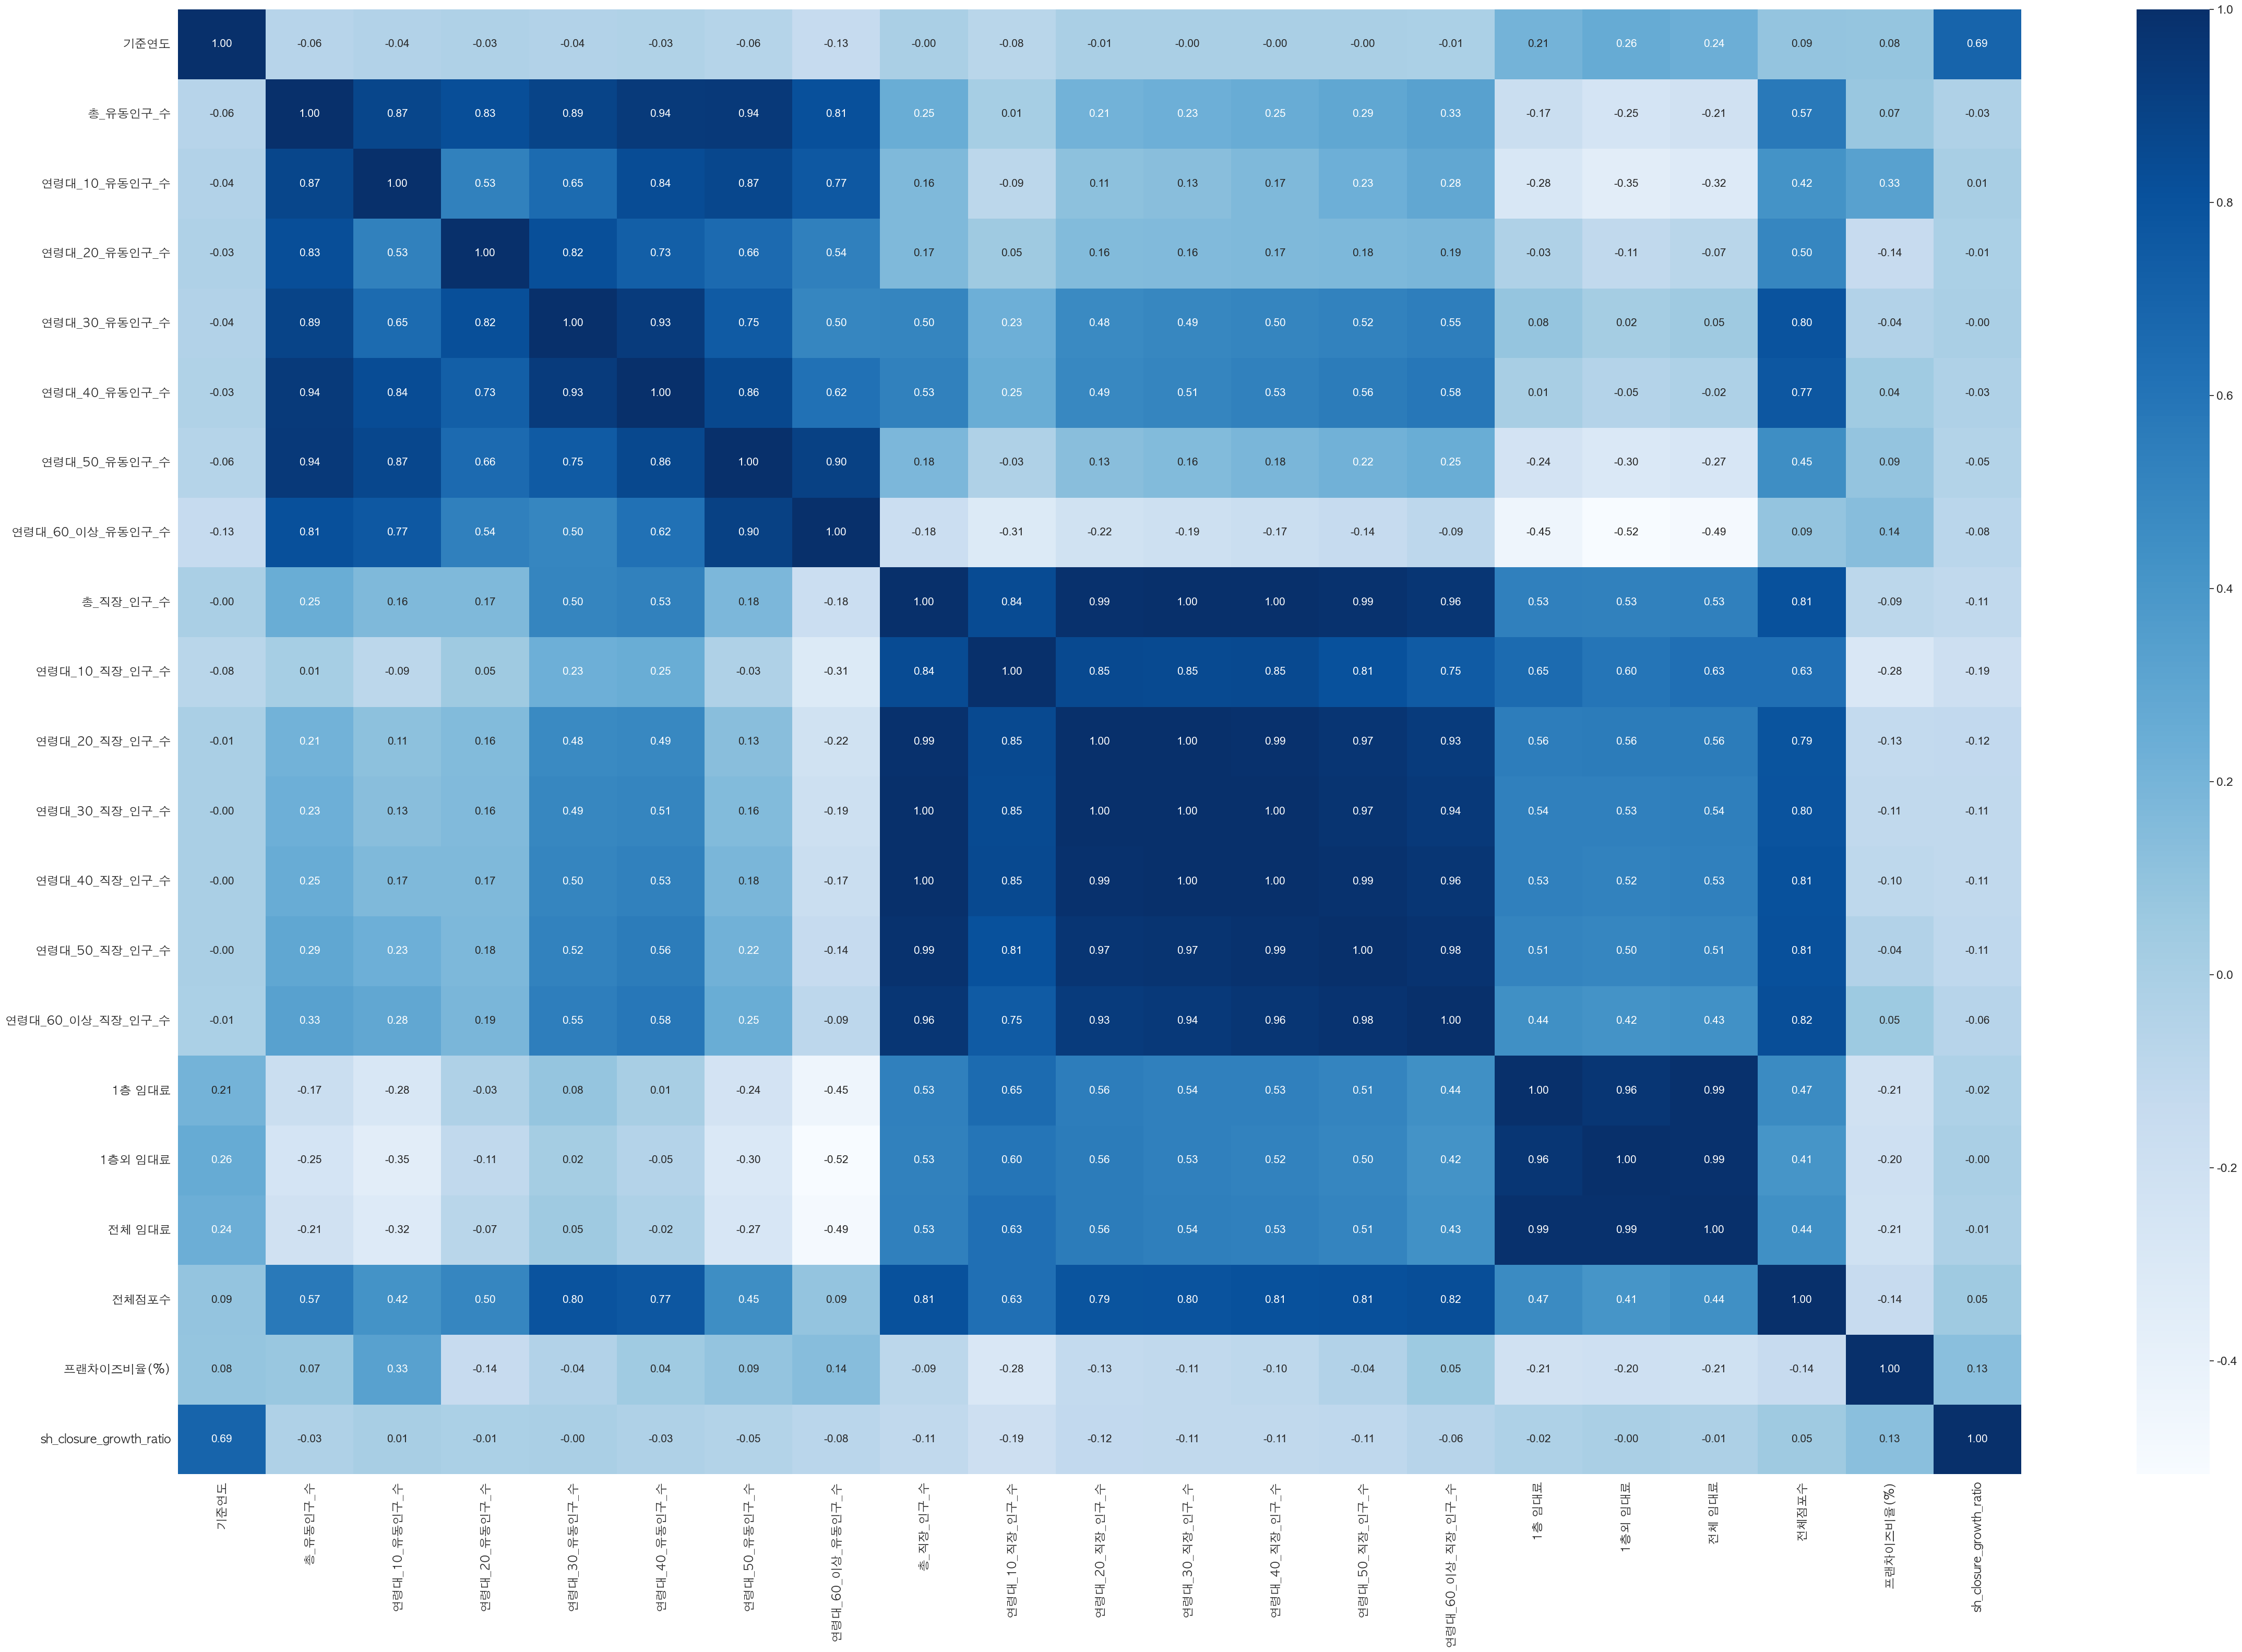

In [18]:
fig = plt.figure(figsize=(48, 32))
ax = fig.gca()

sns.set(font_scale=1.5)
heatmap = sns.heatmap(
    corr.values,
    annot=True,
    fmt='.2f',
    cmap='Blues',  
    annot_kws={'size': 15},
    yticklabels=cols,
    xticklabels=cols,
    ax=ax
)

plt.tight_layout()
plt.show()

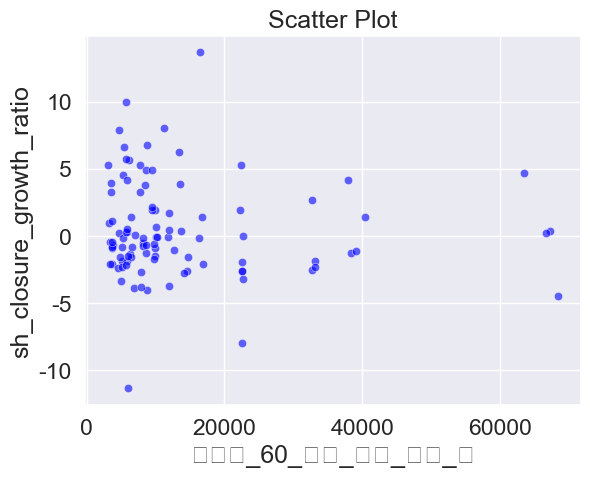

In [21]:
sns.scatterplot(data=df, 
                x='연령대_60_이상_직장_인구_수', y='sh_closure_growth_ratio', 
                markers='o', 
                color='blue',
                alpha=0.6)
plt.title('Scatter Plot')
plt.show()

## [2] 모델링

In [22]:
# 연령대 비율 피처 생성
df['20대_유동_비율'] = df['연령대_20_유동인구_수'] / df['총_유동인구_수']
df['30대_유동_비율'] = df['연령대_30_유동인구_수'] / df['총_유동인구_수']
df['40대_유동_비율'] = df['연령대_40_유동인구_수'] / df['총_유동인구_수']
df['50대_유동_비율'] = df['연령대_50_유동인구_수'] / df['총_유동인구_수']
df['60대이상_유동_비율'] = df['연령대_60_이상_유동인구_수'] / df['총_유동인구_수']
df['20대_직장_비율'] = df['연령대_20_직장_인구_수'] / df['총_직장_인구_수']
df['30대_직장_비율'] = df['연령대_30_직장_인구_수'] / df['총_직장_인구_수']
df['40대_직장_비율'] = df['연령대_40_직장_인구_수'] / df['총_직장_인구_수']
df['50대_직장_비율'] = df['연령대_50_직장_인구_수'] / df['총_직장_인구_수']
df['60대이상_직장_비율'] = df['연령대_60_이상_직장_인구_수'] / df['총_직장_인구_수']

In [23]:
feature_cols = [
    '총_유동인구_수', '총_직장_인구_수',
    '20대_유동_비율', '30대_유동_비율', '40대_유동_비율', '50대_유동_비율', '60대이상_유동_비율',
    '20대_직장_비율', '30대_직장_비율', '40대_직장_비율', '50대_직장_비율', '60대이상_직장_비율',
    '1층 임대료', '1층외 임대료', '전체점포수', '프랜차이즈비율(%)'
]

In [24]:
df_model = df[feature_cols + ['sh_closure_growth_ratio']].dropna()
X = df_model[feature_cols]
y = df_model['sh_closure_growth_ratio']

In [25]:
# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
# Ridge 회귀 (alpha는 CV로 자동 선택)
alphas = np.logspace(-3, 5, 100)
model = RidgeCV(alphas=alphas, cv=5)
model.fit(X_scaled, y)
y_pred = model.predict(X_scaled)

In [27]:
print(f"\n최적 alpha = {model.alpha_:.4f}")
print(f"R² = {r2_score(y, y_pred):.4f}")
print(f"절편 = {model.intercept_:.4f}")


최적 alpha = 0.0010
R² = 0.3542
절편 = 0.4452


In [28]:
# 표준화 계수 (변수 영향력 비교)
coef_df = pd.DataFrame({
    '변수': feature_cols,
    '표준화_계수': model.coef_
})
coef_df['절대값'] = coef_df['표준화_계수'].abs()
coef_df = coef_df.sort_values('절대값', ascending=False).reset_index(drop=True)

In [29]:
print("\n======= Ridge 회귀 계수 (영향력 순) =======")
print(coef_df[['변수', '표준화_계수']].to_string(index=False))


======= Ridge 회귀 계수 (영향력 순) =======
         변수    표준화_계수
60대이상_직장_비율 58.647059
  30대_직장_비율 50.902008
  50대_직장_비율 46.574695
  20대_직장_비율 41.257177
  40대_직장_비율 17.824011
   총_유동인구_수 -3.076190
60대이상_유동_비율 -3.009975
      전체점포수  2.449811
  총_직장_인구_수 -1.427055
     1층 임대료  0.653604
  20대_유동_비율  0.644230
 프랜차이즈비율(%)  0.640801
  30대_유동_비율 -0.628869
    1층외 임대료 -0.474734
  50대_유동_비율  0.333062
  40대_유동_비율 -0.092985
